# СКОРОСТЬ ОТ ВРЕМЕНИ
См. ниже время ограничена t < 0.0004, поскольку большинство бэгов разрываются именно в этом диапазоне 

coefficients
[-3183.13005647     4.51979219]
[-2497.55654607     5.35702336]
[-1178.92785044     4.96456704]
[-1112.56519803     5.34835819]


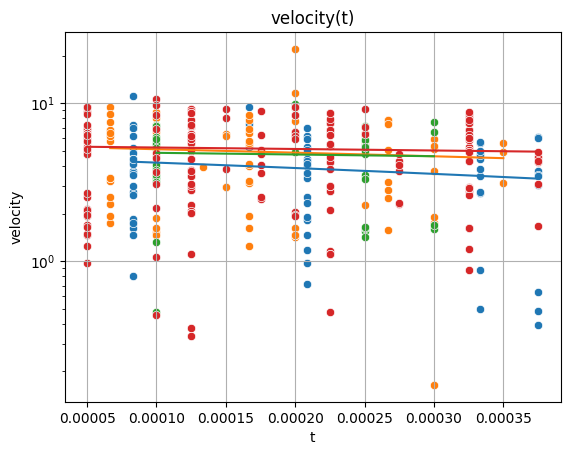

In [18]:
import bags_array_test as bg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

df = pd.read_excel(r"C:\Users\misha\Desktop\output.xlsx").dropna()

df = df[df['t'] < 0.0004]
print('coefficients')
for name, group in df.groupby(by='wind_velocity'):
    sns.scatterplot(x=group['t'], y = group['velocity'])
    coefficients = np.polyfit(group['t'],group['velocity'], 1)
    t = np.linspace(min(group['t']), max(group['t']), 100)
    velocity = coefficients[0]*t  + coefficients[1]
    sns.lineplot(y=velocity,x = t)
    print(coefficients)
plt.yscale('log')
plt.grid()
plt.title('velocity(t)')
plt.show()

# Функция плотности вероятности для времени
Большинство бэгов разрываются до t < 0.0004

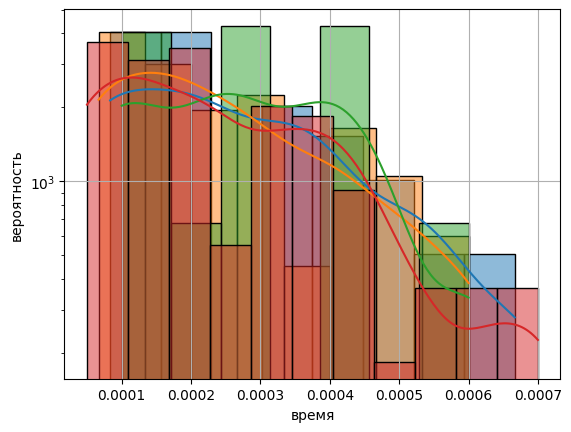

In [127]:
import bags_array_test as bg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

df = pd.read_excel(r"C:\Users\misha\Desktop\output.xlsx").dropna()

for name, group in df.groupby(by='wind_velocity'):
    sns.histplot(x = group['t'], kde = True, stat='density')
plt.yscale('log')
plt.xlabel('время')
plt.ylabel('вероятность')
plt.grid()
plt.show()

# Функция плотности вероятности толщины от времени(dt = 0.0001)

Максимальное значение: 0.7964889000438373


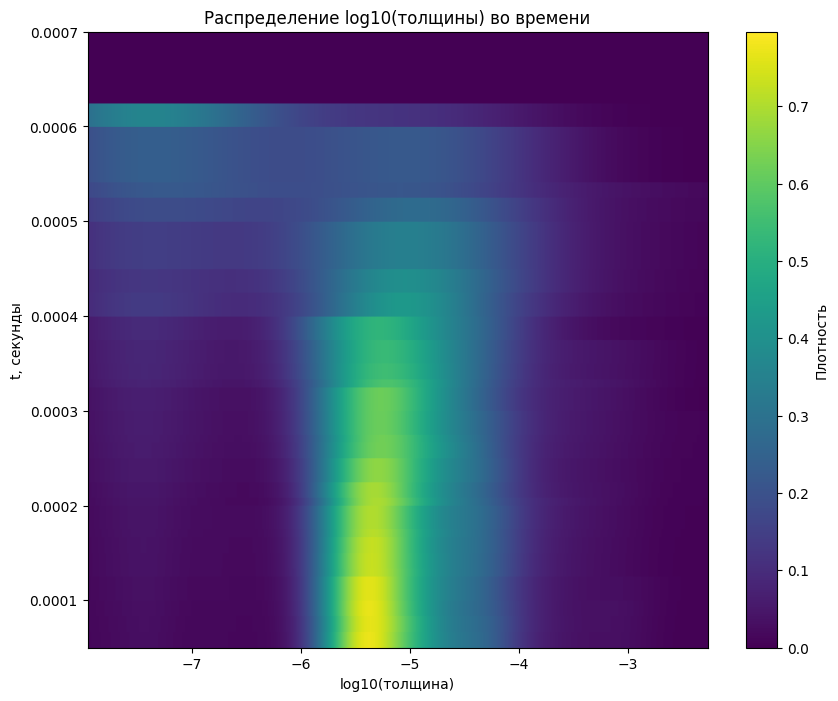

In [50]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import gaussian_kde 

df = pd.read_excel(r"C:\Users\misha\Desktop\output.xlsx").dropna()

# Упрощаем: меньше точек для отладки
num = 1000
n_time = num
n_thick = num

df['thickness'] = (2*0.0728)/(1000*df['velocity']**2)
df['thickness_log10'] = np.log10(df['thickness'])

t = np.linspace(min(df['t']), max(df['t']), n_time)
thickness_log10 = np.linspace(min(df['thickness_log10']), max(df['thickness_log10']), n_thick)

grid_log10 = np.zeros([n_time, n_thick])

dt = 0.001  # увеличиваем окно для захвата большего числа точек

for i, time in enumerate(t):
    df_time = df[(df['t'] > time) & (df['t'] < time + dt)]
    if len(df_time) > 10:  # увеличиваем порог
        kde = gaussian_kde(df_time['thickness_log10'])
        grid_log10[i, :] = kde(thickness_log10)
    else:
        # Если данных мало, ставим маленькие случайные значения
        grid_log10[i, :] = np.zeros(n_thick)

print(f"Максимальное значение: {grid_log10.max()}")

# Рисуем
plt.figure(figsize=(10, 8))
plt.imshow(grid_log10, 
           extent=[min(thickness_log10), max(thickness_log10), min(t), max(t)], 
           aspect='auto',
           origin='lower',
           cmap='viridis')
plt.ylabel('t, секунды')
plt.xlabel('log10(толщина)')
plt.colorbar(label='Плотность')
plt.title('Распределение log10(толщины) во времени')
plt.show()


# Плотности вероятности

Эмпирическое среднее 2.9109194326575927e-05
Мат.ожидание(среднее) 2.05572138365943e-05
Дисперсия 2.1618044433704273e-09
Средне-квадратичное 4.649520882166707e-05
Стандартная ошибка 1.1537272660463293e-07


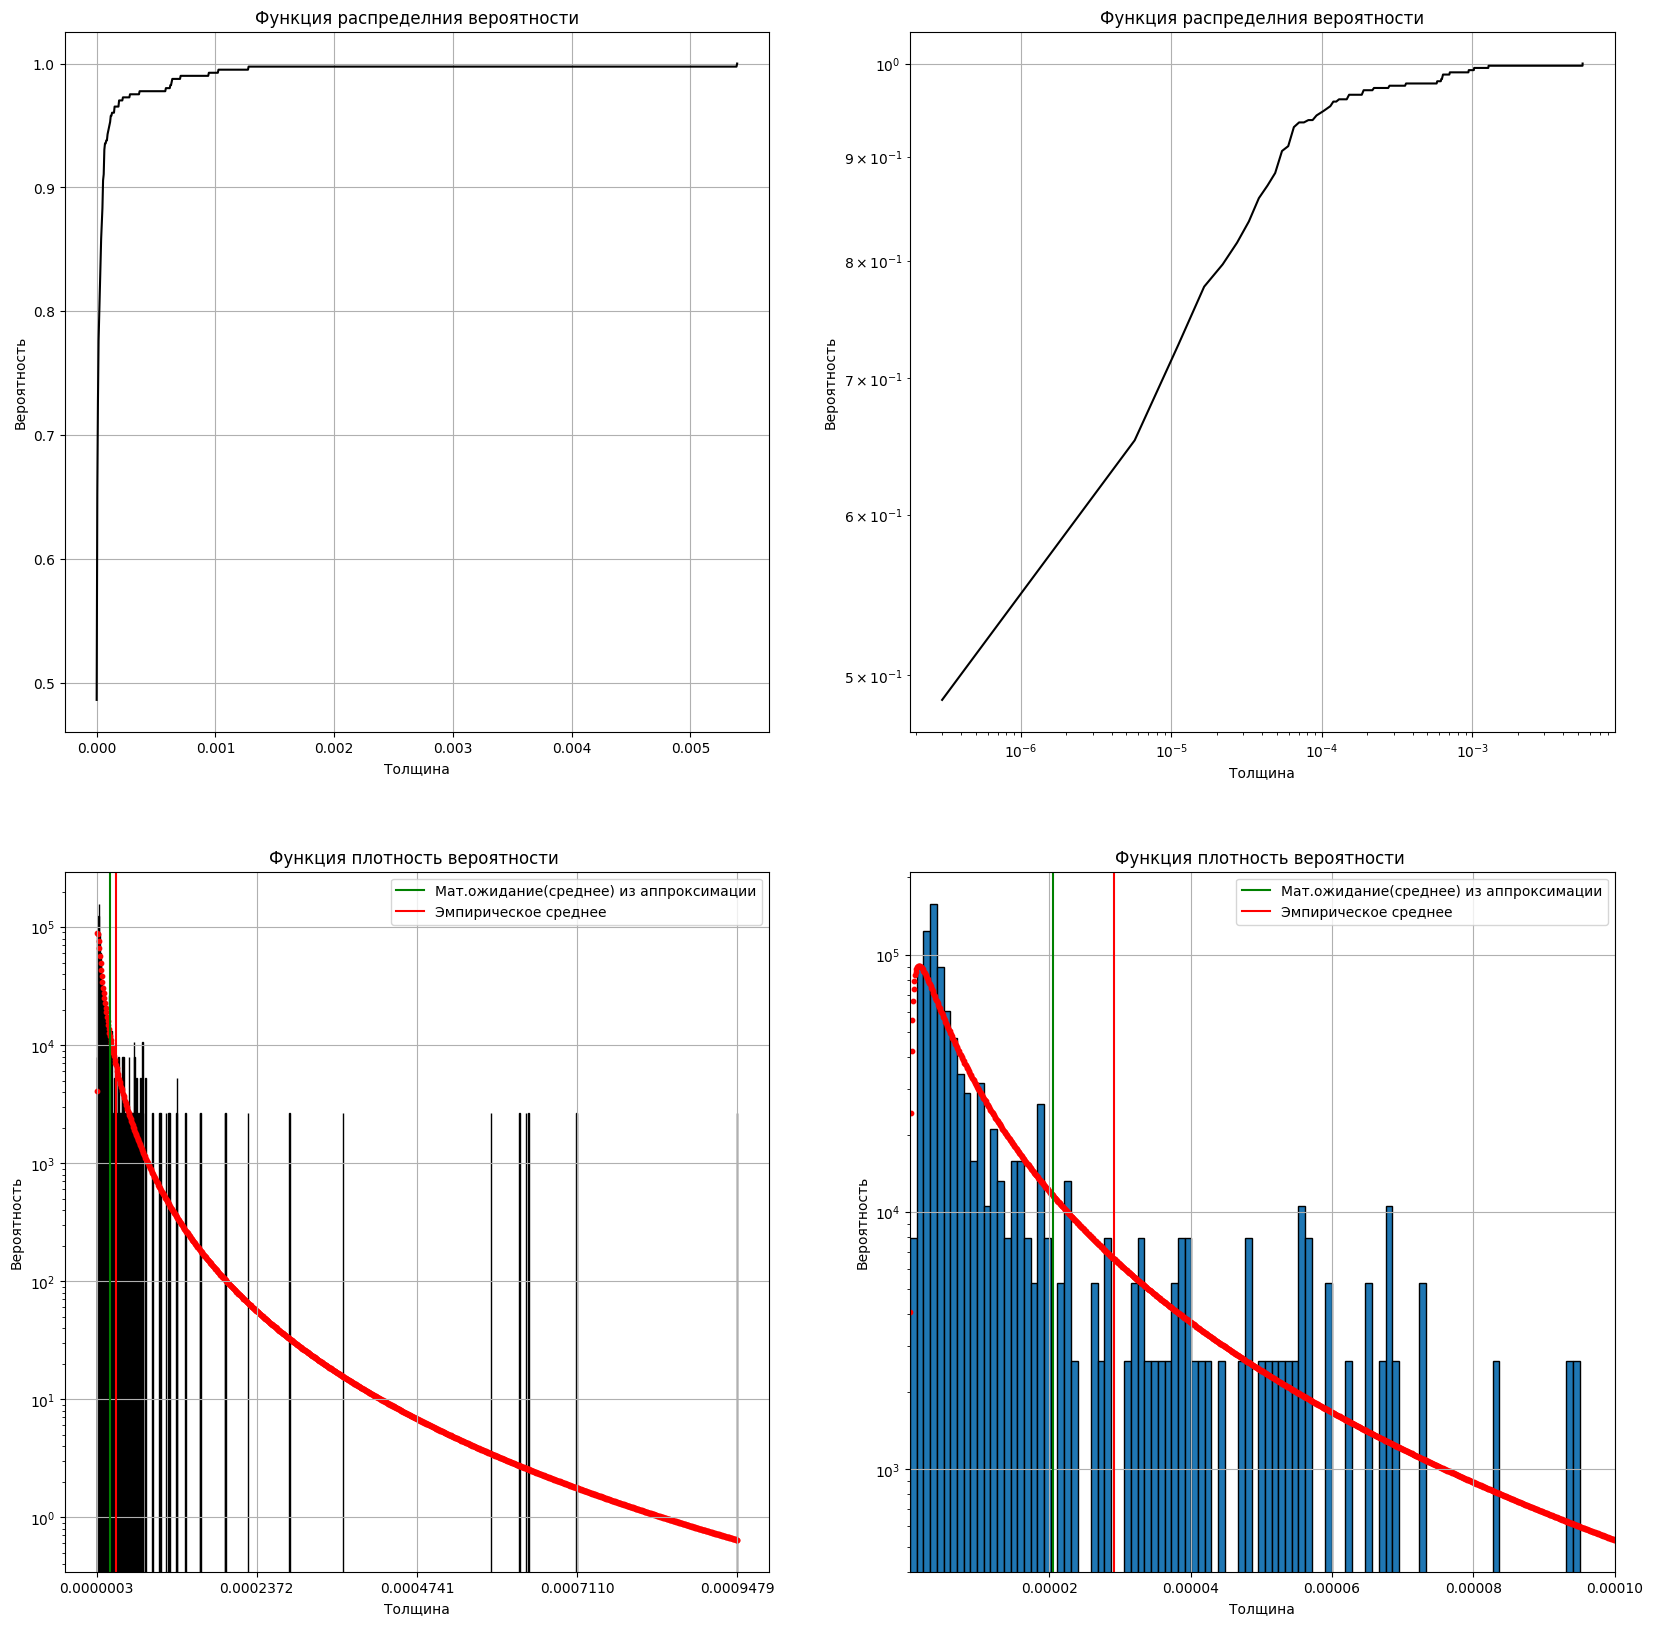

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from scipy.stats import lognorm
from scipy.stats import norm
from scipy.optimize import curve_fit 

BINS = 1000

df = pd.read_excel(r"C:\Users\misha\Desktop\output.xlsx").dropna()

df = df[df['t'] < 0.0004]

df['thickness'] = (2*0.0728)/(1000*df['velocity']**2)



fig, ax = plt.subplots(2,2,figsize=(20,20))


df_1 = df[df['thickness'] < 0.001]


s, loc, scale = lognorm.fit(df_1['thickness'])
mean, var, skew, kurt = lognorm.stats(s, loc=loc, scale=scale, moments='mvsk')


prob, edge = np.histogram(df['thickness'], bins = BINS, density = True)
prob = np.cumsum(prob)/np.sum(prob)
edge = edge[:-1]


ax[0,0].plot(edge,prob,color='black')
ax[0,0].set_title('Функция распределния вероятности')
ax[0,0].set_xlabel('Толщина')
ax[0,0].set_ylabel('Вероятность')
ax[0,0].grid()


mean, var, skew, kurt = lognorm.stats(s, loc = loc, scale = scale, moments='mvsk')

prob, edge = np.histogram(df['thickness'], bins = BINS, density = True)
prob = np.cumsum(prob)/np.sum(prob)
edge = edge[:-1]
ax[0,1].plot(edge,prob,color='black')
ax[0,1].set_title('Функция распределния вероятности')
ax[0,1].set_xlabel('Толщина')
ax[0,1].set_xticks(np.linspace(min(df_1['thickness']), max(df_1['thickness']), 5))
ax[0,1].set_ylabel('Вероятность')
ax[0,1].grid()
# ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')
ax[0,1].set_yscale('log')

x = np.linspace(min(df_1['thickness']), max(df_1['thickness']), 1000)
lognorm_pdf_1 = lognorm.pdf(x, s, loc, scale)

ax[1,0].hist(df_1['thickness'], bins = BINS, density = True, linewidth=1, edgecolor='black')
ax[1,0].scatter(x, lognorm_pdf_1, s = 10, color='red')
ax[1,0].set_title('Функция плотность вероятности ')
ax[1,0].set_xticks(np.linspace(min(df_1['thickness']), max(df_1['thickness']), 5))
ax[1,0].set_xlabel('Толщина')
ax[1,0].set_ylabel('Вероятность')
ax[1,0].set_yscale('log')
ax[1,0].axvline(x = mean, ymin = 0, ymax = 1, color = 'green', label='Мат.ожидание(среднее) из аппроксимации')
ax[1,0].axvline(x = np.mean(df_1['thickness']), ymin = 0, ymax = 1, color = 'red', label = 'Эмпирическое среднее')
ax[1,0].legend()
ax[1,0].grid()


x_max = 1e-4
x = np.linspace(min(df_1['thickness']), x_max, 1000)
lognorm_pdf_2 = lognorm.pdf(x, s, loc, scale)

ax[1,1].hist(df_1['thickness'], bins = BINS, density = True, linewidth=1, edgecolor='black')
ax[1,1].scatter(x, lognorm_pdf_2, s = 10, color='red')
ax[1,1].set_title('Функция плотность вероятности ')
ax[1,1].set_xlabel('Толщина')
ax[1,1].set_ylabel('Вероятность')
ax[1,1].set_yscale('log')
ax[1,1].set_xlim([min(df_1['thickness']), x_max])
ax[1,1].axvline(x = mean, ymin = 0, ymax = 1, color = 'green', label='Мат.ожидание(среднее) из аппроксимации')
ax[1,1].axvline(x = np.mean(df_1['thickness']), ymin = 0, ymax = 1, color = 'red', label = 'Эмпирическое среднее')
ax[1,1].legend()
ax[1,1].grid()
print(f'Эмпирическое среднее {np.mean(df_1['thickness'])}')
print(f'Мат.ожидание(среднее) {mean}')
print(f'Дисперсия {var}')
print(f'Средне-квадратичное {np.sqrt(var)}')
print(f'Стандартная ошибка {np.sqrt(var)/len(df)}')
